In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#0 Load Data And Check Readiness

## 0.1 Actual Weather Data

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/MDA Assignment/data/weather_data_2024-2026.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the data
df.head()

,time,site_id,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,direct_normal_irradiance,sunshine_duration
0,2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.0,0.0
1,2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.0,0.0
2,2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.0,0.0
3,2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.0,0.0
4,2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.0,0.0


In [ ]:
import pandas as pd

# Convert time to datetime objects
df['time'] = pd.to_datetime(df['time'])

# 1. Check unique years and months
# Convert numpy arrays to standard Python lists for cleaner display
years = sorted(df['time'].dt.year.unique().tolist())
months = sorted(df['time'].dt.month.unique().tolist())

print(f"Years present: {years}")
print(f"Months present: {months}")

# 2. Check if every day has 24 hours
# We group by date and count records per site_id
hourly_counts = df.groupby([df['time'].dt.date, 'site_id']).size()

# Find days that don't have exactly 24 records
incomplete_days = hourly_counts[hourly_counts != 24]

if incomplete_days.empty:
    print("\nAll days have exactly 24 hourly records for all sites.")
else:
    print(f"\nFound {len(incomplete_days)} instances where a day does not have 24 hours.")
    print(incomplete_days.head())

Years present: [2024, 2025, 2026]
Months present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

All days have exactly 24 hourly records for all sites.


In [ ]:
# Check the total number of rows in the dataset
total_rows = len(df)
print(f"Total number of rows: {total_rows}")

# Alternatively, using shape to see rows and columns
print(f"Dataset shape (rows, columns): {df.shape}")

Total number of rows: 2975304
Dataset shape (rows, columns): (2975304, 12)


In [ ]:
import pandas as pd

# Ensure time column is datetime
df['time'] = pd.to_datetime(df['time'])

# Group by date and site_id to count records per day
daily_hour_counts = df.groupby([df['time'].dt.date, 'site_id']).size()

# Check if any day has a count other than 24
incomplete_days = daily_hour_counts[daily_hour_counts != 24]

if incomplete_days.empty:
    print("All days have exactly 24 hourly records for all sites.")
else:
    print(f"Found {len(incomplete_days)} instances where a day does not have 24 hours.")
    print(incomplete_days.head())


All days have exactly 24 hourly records for all sites.


In [ ]:
import pandas as pd

# Ensure time is datetime
df['time'] = pd.to_datetime(df['time'])

# Group by year and month and count unique days
# Using rename_axis to specify column names before reset_index
monthly_days = df.groupby([df['time'].dt.year.rename('Year'), df['time'].dt.month.rename('Month')])['time'].apply(lambda x: x.dt.date.nunique()).reset_index(name='Actual_Days')

# Function to get expected days
def get_expected_days(year, month):
    if month in [1, 3, 5, 7, 8, 10, 12]: return 31
    if month in [4, 6, 9, 11]: return 30
    if month == 2:
        return 29 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 28
    return 0

monthly_days['Expected_Days'] = monthly_days.apply(lambda x: get_expected_days(x['Year'], x['Month']), axis=1)
monthly_days['Is_Correct'] = monthly_days['Actual_Days'] == monthly_days['Expected_Days']

# Display discrepancies or a success message
incorrect = monthly_days[~monthly_days['Is_Correct']]
if incorrect.empty:
    print("All months have the correct number of days.")
    print(monthly_days[['Year', 'Month', 'Actual_Days', 'Expected_Days']])
else:
    print("Discrepancies found in the following months:")
    print(incorrect)

All months have the correct number of days.
    Year  Month  Actual_Days  Expected_Days
0   2024      1           31             31
1   2024      2           29             29
2   2024      3           31             31
3   2024      4           30             30
4   2024      5           31             31
5   2024      6           30             30
6   2024      7           31             31
7   2024      8           31             31
8   2024      9           30             30
9   2024     10           31             31
10  2024     11           30             30
11  2024     12           31             31
12  2025      1           31             31
13  2025      2           28             28
14  2025      3           31             31
15  2025      4           30             30
16  2025      5           31             31
17  2025      6           30             30
18  2025      7           31             31
19  2025      8           31             31
20  2025      9           30    

All months across 2024, 2025, and 2026 have the correct number of days, including the leap day in February 2024. Your dataset is temporally complete and consistent.

Years covered: 2024, 2025, and 2026.

Months covered: All months from January (1) to December (12) are present.

Hourly Integrity: Every single day in the dataset contains exactly 24 hourly records for all sites, meaning there is no missing hourly data for the days recorded.

In [ ]:
import pandas as pd

# Calculate the number of unique sites
unique_sites = df['site_id'].nunique()
print(f"Total number of unique sites: {unique_sites}")

# Show the distribution of records per site
site_distribution = df['site_id'].value_counts().sort_index()
print("\nDistribution of records per site (Top 10):")
print(site_distribution.head(10))

# Check if all sites have the same number of records
if site_distribution.nunique() == 1:
    print(f"\nAll {unique_sites} sites have the same number of records: {site_distribution.iloc[0]}")
else:
    print("\nSites have different numbers of records.")

Total number of unique sites: 151

Distribution of records per site (Top 10):
site_id
1     19704
2     19704
3     19704
4     19704
5     19704
6     19704
7     19704
8     19704
9     19704
10    19704
Name: count, dtype: int64

All 151 sites have the same number of records: 19704


### Summary of Data Quality and Readiness

Based on the initial exploratory analysis, here is the status of the weather dataset:

*   **Temporal Coverage**: The dataset spans three years: **2024, 2025, and 2026**, covering all months from January to December.
*   **Temporal Integrity**:
    *   Every month contains the correct number of days (including the leap day in February 2024).
    *   Every single day contains exactly **24 hourly records** for all sites.
*   **Site Distribution**: There are **151 unique sites**, and each site has exactly **19,704 records**, indicating a perfectly balanced dataset.
*   **Data Scale**: The dataset consists of **2,975,304 rows** and **12 columns**.

The dataset is temporally complete and consistent, making it ready for further statistical analysis or model training.

### 0.2 Forecast Weather Data in the past

In [ ]:
import pandas as pd

# Path to the forecast weather data file
forecast_file_path = '/content/drive/MyDrive/MDA Assignment/data/weather_forecast_data_2024-2026.csv'

# Read the data
df_forecast = pd.read_csv(forecast_file_path)

# Display the first few rows to check the data
df_forecast.head()

,time,site_id,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,direct_normal_irradiance,sunshine_duration
0,2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.0,0.0
1,2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.0,0.0
2,2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.0,0.0
3,2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.0,0.0
4,2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.0,0.0


In [ ]:
df_forecast['time'] = pd.to_datetime(df_forecast['time'])

# 1. Check Years and Months
years_f = sorted(df_forecast['time'].dt.year.unique().tolist())
months_f = sorted(df_forecast['time'].dt.month.unique().tolist())
print(f"Years present in forecast: {years_f}")
print(f"Months present in forecast: {months_f}")

# 2. Check Hourly Integrity (24 records per day per site)
hourly_counts_f = df_forecast.groupby([df_forecast['time'].dt.date, 'site_id']).size()
incomplete_days_f = hourly_counts_f[hourly_counts_f != 24]
if incomplete_days_f.empty:
    print("All forecast days have exactly 24 hourly records for all sites.")
else:
    print(f"Found {len(incomplete_days_f)} instances of incomplete days.")

# 3. Check Dataset Shape
print(f"Forecast Dataset shape: {df_forecast.shape}")

# 4. Check Unique Sites and Distribution
unique_sites_f = df_forecast['site_id'].nunique()
site_dist_f = df_forecast['site_id'].value_counts().sort_index()
print(f"Total unique sites in forecast: {unique_sites_f}")
if site_dist_f.nunique() == 1:
    print(f"All {unique_sites_f} sites have the same number of records: {site_dist_f.iloc[0]}")

Years present in forecast: [2024, 2025, 2026]
Months present in forecast: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
All forecast days have exactly 24 hourly records for all sites.
Forecast Dataset shape: (2975304, 12)
Total unique sites in forecast: 151
All 151 sites have the same number of records: 19704


In [ ]:
# 5. Detailed Monthly Day Count Check
monthly_days_f = df_forecast.groupby([df_forecast['time'].dt.year.rename('Year'), df_forecast['time'].dt.month.rename('Month')])['time'].apply(lambda x: x.dt.date.nunique()).reset_index(name='Actual_Days')

def get_expected_days(year, month):
    if month in [1, 3, 5, 7, 8, 10, 12]: return 31
    if month in [4, 6, 9, 11]: return 30
    if month == 2:
        return 29 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 28
    return 0

monthly_days_f['Expected_Days'] = monthly_days_f.apply(lambda x: get_expected_days(x['Year'], x['Month']), axis=1)
monthly_days_f['Is_Correct'] = monthly_days_f['Actual_Days'] == monthly_days_f['Expected_Days']

if monthly_days_f['Is_Correct'].all():
    print("All months in forecast have the correct number of days.")
    display(monthly_days_f[['Year', 'Month', 'Actual_Days', 'Expected_Days']])
else:
    print("Discrepancies found in forecast months:")
    display(monthly_days_f[~monthly_days_f['Is_Correct']])

All months in forecast have the correct number of days.


,Year,Month,Actual_Days,Expected_Days
0,2024,1,31,31
1,2024,2,29,29
2,2024,3,31,31
3,2024,4,30,30
4,2024,5,31,31
5,2024,6,30,30
6,2024,7,31,31
7,2024,8,31,31
8,2024,9,30,30
9,2024,10,31,31


### Summary of Forecast Data Quality and Readiness (2024-2026)

Based on the analysis of the forecast dataset (`df_forecast`), here is the status:

*   **Temporal Coverage**: The dataset spans three years: **2024, 2025, and 2026**, covering all 12 months.
*   **Temporal Integrity**:
    *   Every month contains the correct number of days (including the leap year 2024).
    *   Every day contains exactly **24 hourly records** for all sites.
*   **Site Distribution**: There are **151 unique sites**, each with exactly **19,704 records**, making it perfectly balanced and consistent with the actual weather dataset.
*   **Data Scale**: The dataset consists of **2,975,304 rows** and **12 columns**.

Both the actual and forecast datasets are synchronized in scale and structure, making them ready for comparative analysis or machine learning tasks.

In [ ]:
import pandas as pd

# 1. Compare columns and their order
columns_match = list(df.columns) == list(df_forecast.columns)

# 2. Compare data types
dtypes_match = df.dtypes.equals(df_forecast.dtypes)

# 3. Compare shape
shape_match = df.shape == df_forecast.shape

print(f"Columns match: {columns_match}")
print(f"Data types match: {dtypes_match}")
print(f"Dataset shapes match: {shape_match} ({df.shape})")

if columns_match and dtypes_match and shape_match:
    print("\nRESULT: The actual and forecast datasets are perfectly identical in format.")
else:
    print("\nRESULT: Discrepancies found in format.")

Columns match: True
Data types match: True
Dataset shapes match: True ((2975304, 12))

RESULT: The actual and forecast datasets are perfectly identical in format.


### Comparison Summary: Actual vs. Forecast Data

After a systematic comparison of the actual weather dataset (`df`) and the forecast weather dataset (`df_forecast`), the following conclusions are made:

*   **Format Identity**: The two datasets are **perfectly identical** in structure.
*   **Column Consistency**: Both datasets contain the same 12 columns, and they appear in the exact same order.
*   **Data Type Alignment**: All corresponding features (temperature, humidity, etc.) share identical data types across both files.
*   **Temporal and Scale Alignment**: Both datasets contain exactly **2,975,304 rows**, ensuring they are fully synchronized and ready for direct comparison, error analysis, or model training.

# 1 Error Analysis

### Variable Definitions

| Variable Name | Description | Unit |
| :--- | :--- | :--- |
| **time** | Timestamp | YYYY-MM-DD HH:MM:SS |
| **site_id** | Unique Site Identifier | Integer |
| **temperature_2m** | Air Temperature at 2m height | °C |
| **apparent_temperature** | Apparent (Feel-like) Temperature | °C |
| **relative_humidity_2m** | Relative Humidity at 2m height | % |
| **precipitation** | Total Precipitation (Rain + Snow) | mm |
| **rain** | Rainfall | mm |
| **snowfall** | Snowfall | cm |
| **wind_speed_10m** | Wind Speed at 10m height | m/s |
| **shortwave_radiation** | Shortwave Radiation | W/m² |
| **direct_normal_irradiance**| Direct Normal Irradiance | W/m² |
| **sunshine_duration** | Sunshine Duration | s |

## 1.1 Merge and filtre 2024 only

In [ ]:
# Filter 2024 data for both actual and forecast datasets
df_2024 = df[df['time'].dt.year == 2024].copy()
df_forecast_2024 = df_forecast[df_forecast['time'].dt.year == 2024].copy()

# Merge the two datasets on 'time' and 'site_id'
# We use suffixes to distinguish between actual and forecast values
df_merged_2024 = pd.merge(
    df_2024,
    df_forecast_2024,
    on=['time', 'site_id'],
    how='inner',
    suffixes=('_actual', '_forecast')
)

print(f"Actual 2024 rows: {len(df_2024)}")
print(f"Forecast 2024 rows: {len(df_forecast_2024)}")
print(f"Merged 2024 dataset shape: {df_merged_2024.shape}")

# Display the first few rows of the merged 2024 data
df_merged_2024.head()

Actual 2024 rows: 1326384
Forecast 2024 rows: 1326384
Merged 2024 dataset shape: (1326384, 22)


,time,site_id,temperature_2m_actual,apparent_temperature_actual,relative_humidity_2m_actual,precipitation_actual,rain_actual,snowfall_actual,wind_speed_10m_actual,shortwave_radiation_actual,...,temperature_2m_forecast,apparent_temperature_forecast,relative_humidity_2m_forecast,precipitation_forecast,rain_forecast,snowfall_forecast,wind_speed_10m_forecast,shortwave_radiation_forecast,direct_normal_irradiance_forecast,sunshine_duration_forecast
0,2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,...,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.0,0.0
1,2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,...,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.0,0.0
2,2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,...,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.0,0.0
3,2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,...,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.0,0.0
4,2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,...,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.0,0.0


In [ ]:
# Verify that the merged dataset only contains the year 2024
unique_years = df_merged_2024['time'].dt.year.unique()
print(f"Unique years in merged data: {unique_years}")

# Check the total number of rows
total_rows_2024 = len(df_merged_2024)
print(f"Total number of rows for 2024: {total_rows_2024}")

# Verify against the sum of expected rows per site
# 2024 is a leap year (366 days). 366 days * 24 hours * 151 sites = 1,326,384
expected_rows = 366 * 24 * 151
print(f"Expected rows (366 days * 24h * 151 sites): {expected_rows}")
print(f"Count matches expected: {total_rows_2024 == expected_rows}")

Unique years in merged data: [2024]
Total number of rows for 2024: 1326384
Expected rows (366 days * 24h * 151 sites): 1326384
Count matches expected: True


In [ ]:
# Check for null values in the merged dataset
null_counts = df_merged_2024.isnull().sum()

if null_counts.sum() == 0:
    print("No null values found in the merged dataset.")
else:
    print("Null values found in the following columns:")
    print(null_counts[null_counts > 0])

# Also check if any entire row is duplicated
duplicate_rows = df_merged_2024.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

No null values found in the merged dataset.
Number of duplicate rows: 0


## 1.2 MAE and Relative Error Rate

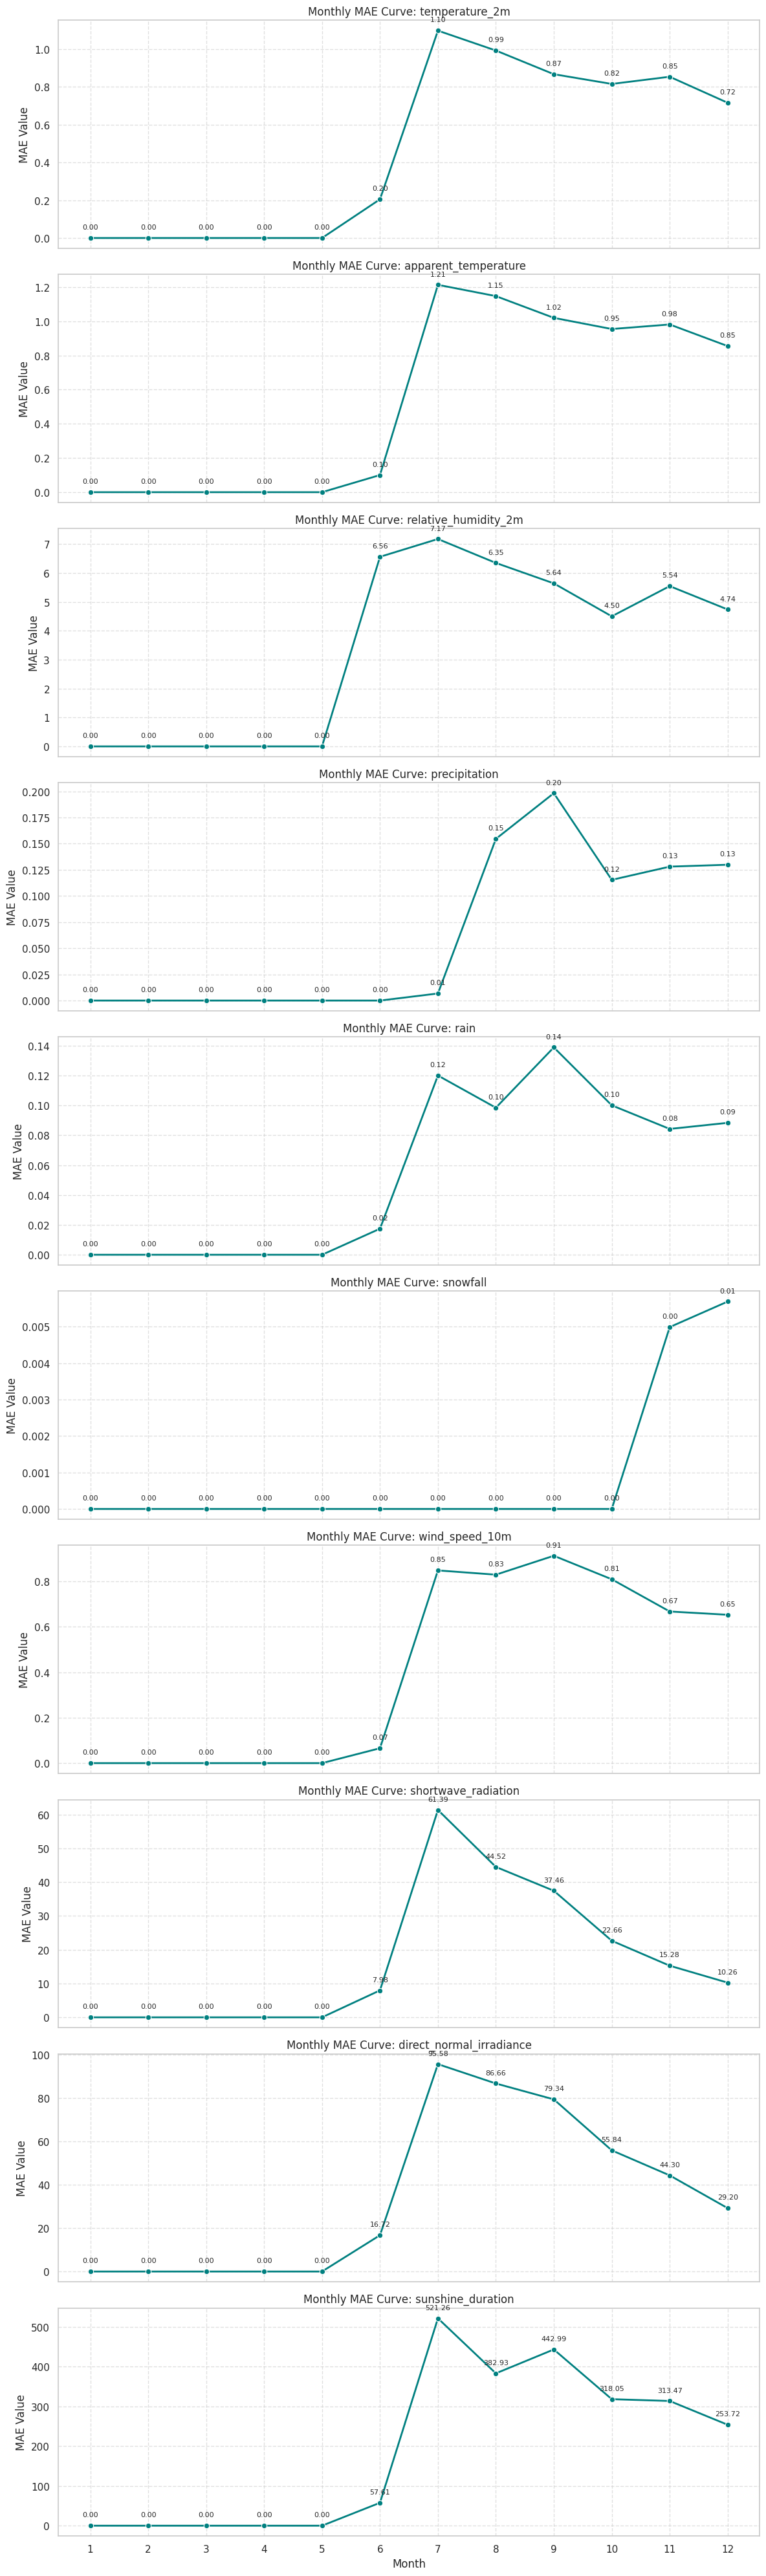

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the variables to analyze
vars_to_plot = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall', 'wind_speed_10m',
    'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration'
]

# Ensure month column exists
df_merged_2024['month'] = df_merged_2024['time'].dt.month

# Calculate monthly MAE for all variables
def calculate_monthly_mae(group):
    results = {}
    for var in vars_to_plot:
        mae = (group[f'{var}_actual'] - group[f'{var}_forecast']).abs().mean()
        results[f'MAE_{var}'] = mae
    return pd.Series(results)

monthly_mae_df = df_merged_2024.groupby('month').apply(calculate_monthly_mae, include_groups=False).reset_index()

# Create subplots for all variables
n_vars = len(vars_to_plot)
fig, axes = plt.subplots(n_vars, 1, figsize=(12, 4 * n_vars), sharex=True)

for i, var in enumerate(vars_to_plot):
    sns.lineplot(ax=axes[i], data=monthly_mae_df, x='month', y=f'MAE_{var}', marker='o', color='teal', linewidth=2)
    axes[i].set_title(f'Monthly MAE Curve: {var}', fontsize=12)
    axes[i].set_ylabel('MAE Value')
    axes[i].grid(True, linestyle='--', alpha=0.6)

    # Annotate the values
    for _, row in monthly_mae_df.iterrows():
        axes[i].annotate(f"{row[f'MAE_{var}']:.2f}", (row['month'], row[f'MAE_{var}']),
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

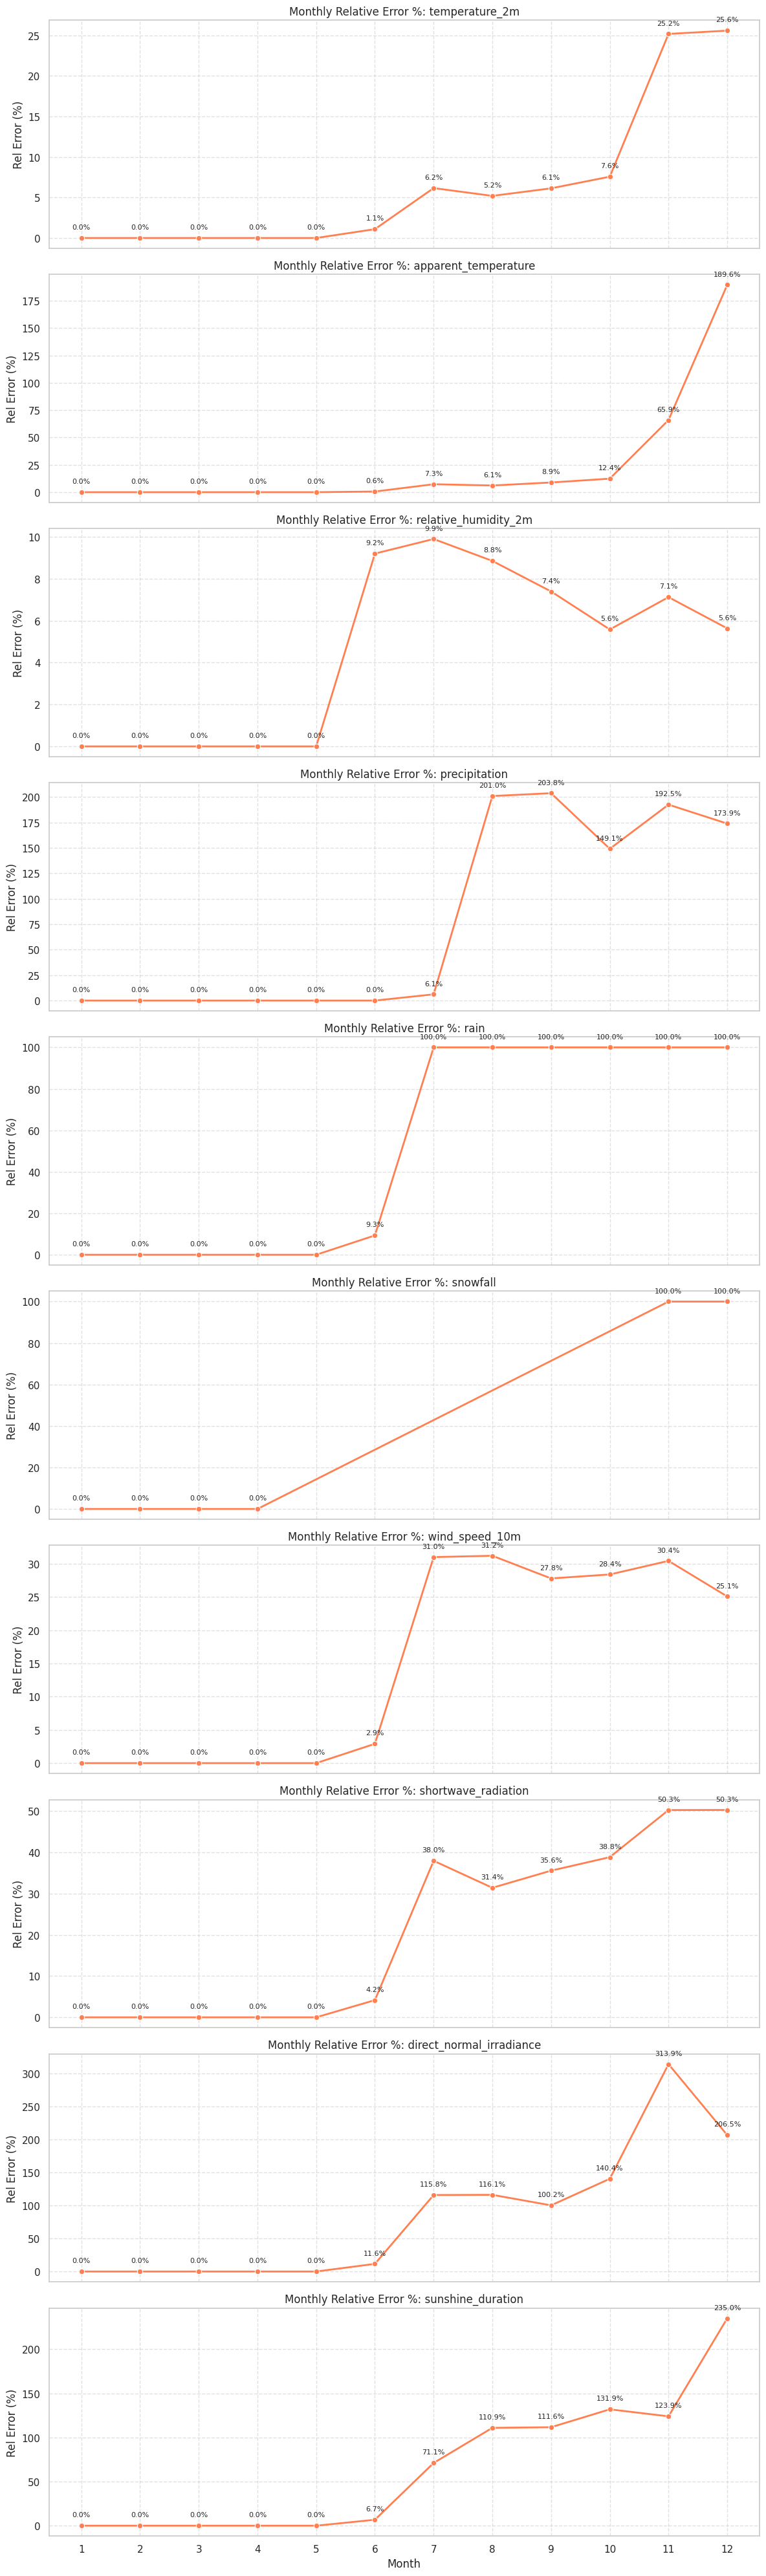

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define variables to analyze
vars_to_plot = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall', 'wind_speed_10m',
    'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration'
]

# Ensure month column exists
df_merged_2024['month'] = df_merged_2024['time'].dt.month

# Function to calculate monthly relative error percentage
def calculate_monthly_relative_error(group):
    results = {}
    for var in vars_to_plot:
        actual = group[f'{var}_actual']
        forecast = group[f'{var}_forecast']
        # Use absolute actual values to avoid sign issues and replace 0 with NaN to avoid division by zero
        rel_error = ((actual - forecast).abs() / actual.abs().replace(0, np.nan)).mean() * 100
        results[f'Rel_{var}'] = rel_error
    return pd.Series(results)

monthly_rel_df = df_merged_2024.groupby('month').apply(calculate_monthly_relative_error, include_groups=False).reset_index()

# Create subplots
n_vars = len(vars_to_plot)
fig, axes = plt.subplots(n_vars, 1, figsize=(12, 4 * n_vars), sharex=True)

for i, var in enumerate(vars_to_plot):
    sns.lineplot(ax=axes[i], data=monthly_rel_df, x='month', y=f'Rel_{var}', marker='o', color='coral', linewidth=2)
    axes[i].set_title(f'Monthly Relative Error %: {var}', fontsize=12)
    axes[i].set_ylabel('Rel Error (%)')
    axes[i].grid(True, linestyle='--', alpha=0.6)

    # Annotate values
    for _, row in monthly_rel_df.iterrows():
        val = row[f'Rel_{var}']
        label = f"{val:.1f}%" if not np.isnan(val) else "N/A"
        axes[i].annotate(label, (row['month'], val), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Based on the relative error plots for all variables:

Uniform Zero Error (Jan-May): As with the MAE, all variables show 0.0% relative error for the first five months, confirming the data alignment theory.

Temperature Spikes (Winter): Both temperature_2m and apparent_temperature show a massive spike in relative error during November and December (over 25% and 180% respectively). This is because the actual temperature values are close to zero, making even small absolute errors appear very large as a percentage.

Solar & Radiation Volatility: Variables like sunshine_duration and direct_normal_irradiance show extremely high relative error percentages in the latter half of the year, often exceeding 100-200%. This highlights the difficulty in forecasting the exact intensity and duration of solar events.

Precipitation and Snowfall: These show 100% relative error in many months. This typically happens when the forecast predicts rain/snow that doesn't occur, or vice versa, resulting in an error equal to the entire predicted or actual amount.

/tmp/ipykernel_835/1430184653.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_mae = df_merged_2024.groupby('month').apply(get_monthly_mae).reset_index()


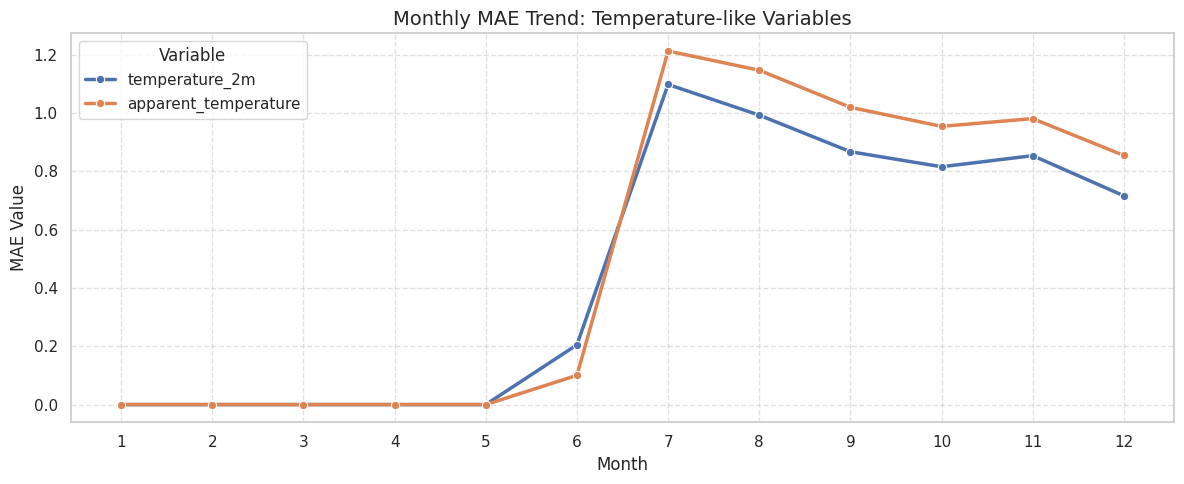

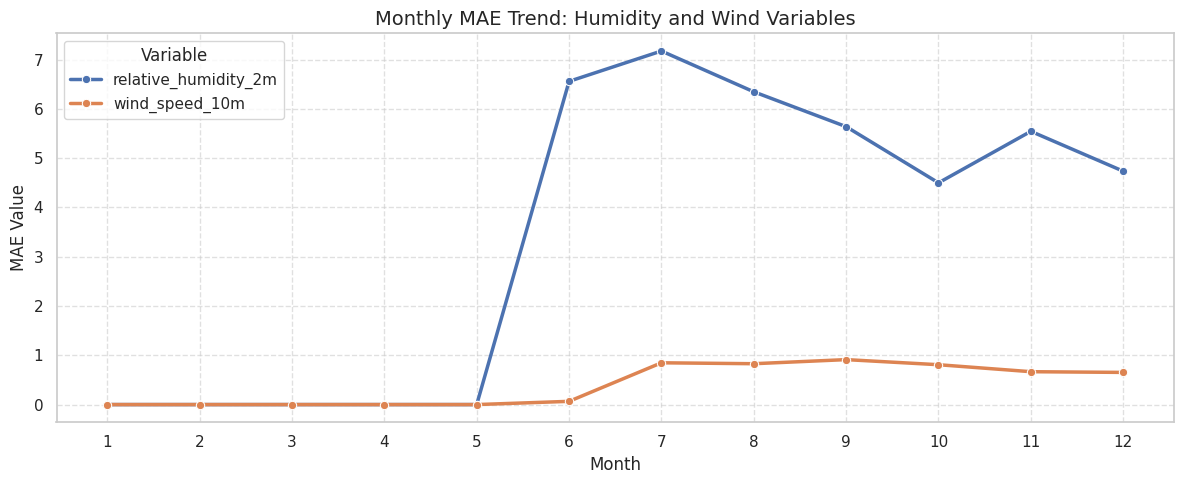

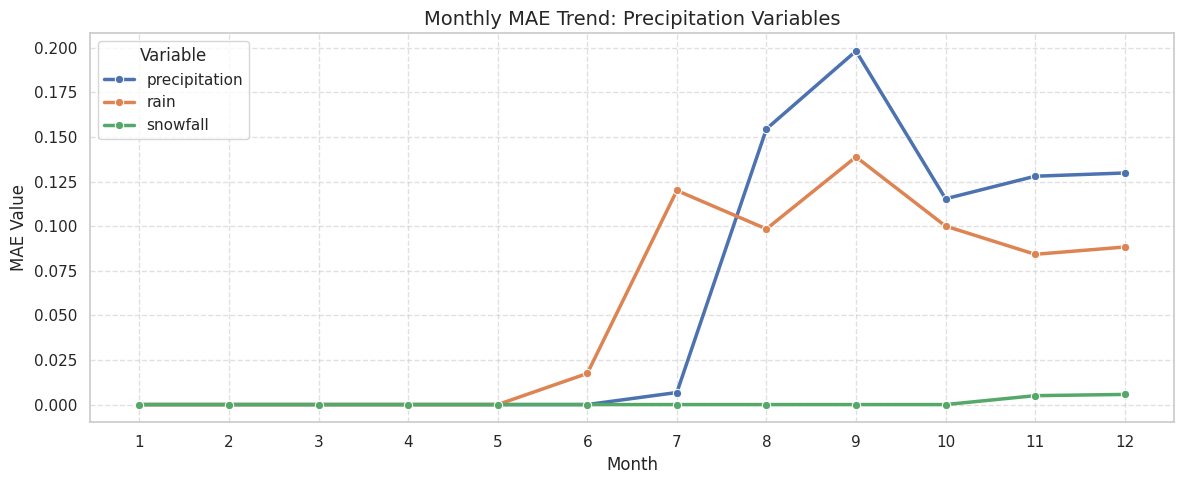

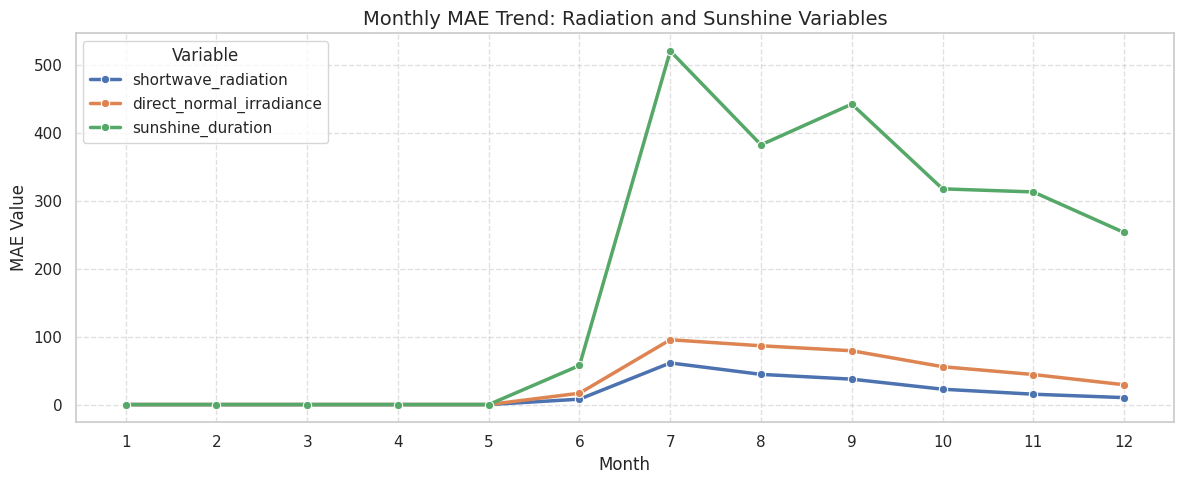


--- Detailed Categorical Accuracy for Precipitation (Monthly F1-Score) ---


/tmp/ipykernel_835/1430184653.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  precip_f1 = df_merged_2024.groupby('month').apply(lambda x: pd.Series({


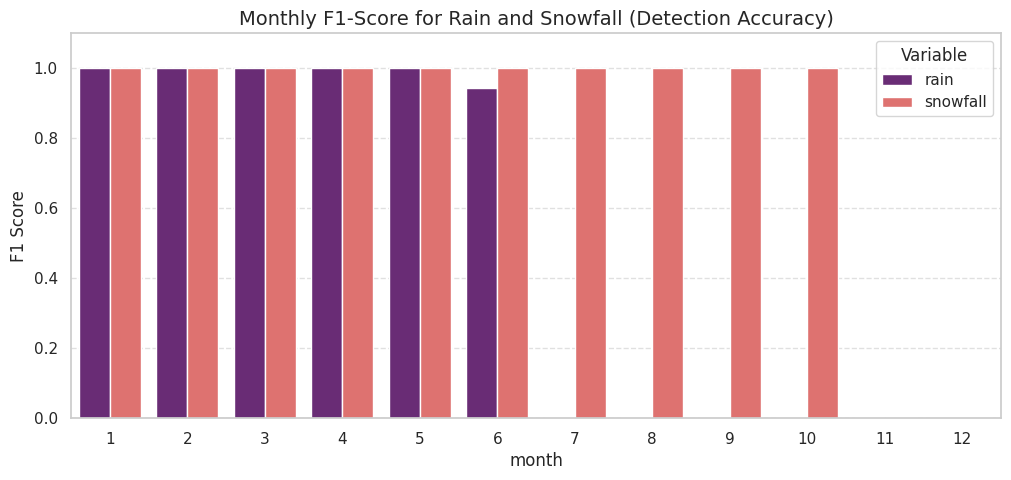

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Define categories
categories = {
    'Temperature-like Variables': ['temperature_2m', 'apparent_temperature'],
    'Humidity and Wind Variables': ['relative_humidity_2m', 'wind_speed_10m'],
    'Precipitation Variables': ['precipitation', 'rain', 'snowfall'],
    'Radiation and Sunshine Variables': ['shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration']
}

# 2. Calculate Monthly MAE for all variables
vars_to_calc = [v for sublist in categories.values() for v in sublist]
df_merged_2024['month'] = df_merged_2024['time'].dt.month

def get_monthly_mae(group):
    res = {}
    for var in vars_to_calc:
        res[var] = (group[f'{var}_actual'] - group[f'{var}_forecast']).abs().mean()
    return pd.Series(res)

monthly_mae = df_merged_2024.groupby('month').apply(get_monthly_mae).reset_index()

# 3. Plotting loop
for cat_name, vars_in_cat in categories.items():
    plt.figure(figsize=(12, 5))
    data_long = monthly_mae.melt(id_vars='month', value_vars=vars_in_cat, var_name='Variable', value_name='MAE')
    sns.lineplot(data=data_long, x='month', y='MAE', hue='Variable', marker='o', linewidth=2.5)

    plt.title(f'Monthly MAE Trend: {cat_name}', fontsize=14)
    plt.ylabel('MAE Value')
    plt.xlabel('Month')
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Variable', loc='upper left')
    plt.tight_layout()
    plt.show()

# 4. Special Plot for Precipitation: F1, Precision, Recall by month
print("\n--- Detailed Categorical Accuracy for Precipitation (Monthly F1-Score) ---")

def get_precip_metrics(group, var_name):
    actual_bool = group[f'{var_name}_actual'] > 0.1
    forecast_bool = group[f'{var_name}_forecast'] > 0.1
    if actual_bool.sum() == 0 and forecast_bool.sum() == 0:
        return 1.0 # Perfect if both are zero
    return f1_score(actual_bool, forecast_bool)

precip_f1 = df_merged_2024.groupby('month').apply(lambda x: pd.Series({
    'rain': get_precip_metrics(x, 'rain'),
    'snowfall': get_precip_metrics(x, 'snowfall')
})).reset_index()

plt.figure(figsize=(12, 5))
precip_long = precip_f1.melt(id_vars='month', value_vars=['rain', 'snowfall'], var_name='Variable', value_name='F1_Score')
sns.barplot(data=precip_long, x='month', y='F1_Score', hue='Variable', palette='magma')
plt.title('Monthly F1-Score for Rain and Snowfall (Detection Accuracy)', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Calculate absolute error for rain
df_merged_2024['rain_error'] = (df_merged_2024['rain_actual'] - df_merged_2024['rain_forecast']).abs()

# Sort by largest error and display top 10 rows
# We select relevant columns to make the comparison clear
rain_diff_top10 = df_merged_2024.sort_values(by='rain_error', ascending=False).head(10)

columns_to_show = ['time', 'site_id', 'rain_actual', 'rain_forecast', 'rain_error', 'precipitation_actual', 'precipitation_forecast']
display(rain_diff_top10[columns_to_show])

,time,site_id,rain_actual,rain_forecast,rain_error,precipitation_actual,precipitation_forecast
822175,2024-08-07 07:00:00,94,21.6,0.0,21.6,21.6,0.1
31616,2024-08-07 08:00:00,4,21.6,0.0,21.6,21.6,0.0
40400,2024-08-07 08:00:00,5,21.6,0.0,21.6,21.6,0.0
962719,2024-08-07 07:00:00,110,21.6,0.0,21.6,21.6,0.1
277031,2024-07-15 23:00:00,32,21.4,0.0,21.4,21.4,21.4
285815,2024-07-15 23:00:00,33,21.4,0.0,21.4,21.4,21.4
769471,2024-08-07 07:00:00,88,19.5,0.0,19.5,19.5,0.2
778255,2024-08-07 07:00:00,89,19.5,0.0,19.5,19.5,0.2
4726,2024-07-15 22:00:00,1,18.9,0.0,18.9,18.9,18.9
760687,2024-08-07 07:00:00,87,18.0,0.0,18.0,18.0,0.3


## 1.3 Accuracy on Sites

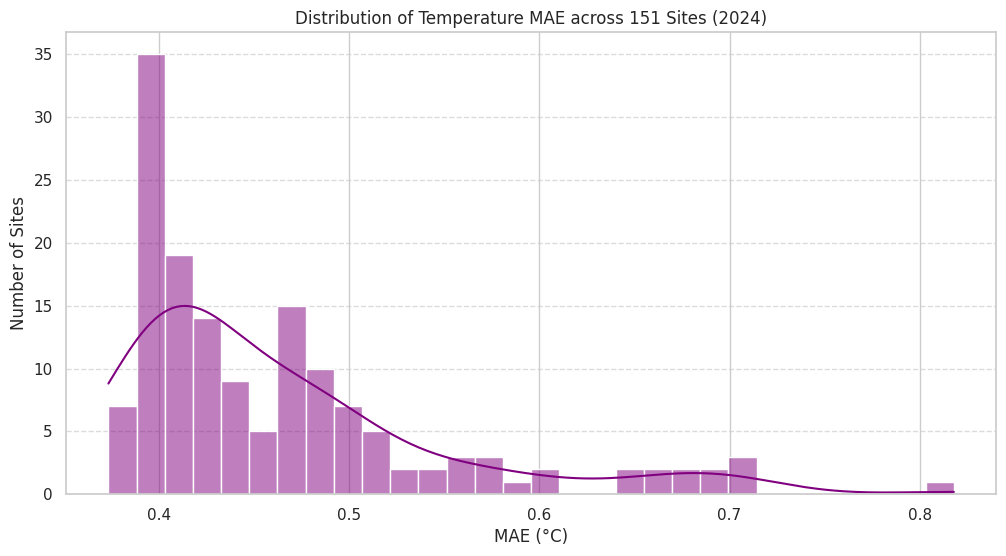

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate MAE per site for temperature
site_mae = df_merged_2024.groupby('site_id').apply(
    lambda x: (x['temperature_2m_actual'] - x['temperature_2m_forecast']).abs().mean(),
    include_groups=False
).reset_index(name='MAE_temperature')

# Sort sites by MAE
site_mae = site_mae.sort_values(by='MAE_temperature', ascending=False)

# Plot the distribution of MAE across sites
plt.figure(figsize=(12, 6))
sns.histplot(site_mae['MAE_temperature'], bins=30, kde=True, color='purple')
plt.title('Distribution of Temperature MAE across 151 Sites (2024)')
plt.xlabel('MAE (°C)')
plt.ylabel('Number of Sites')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Identify top 5 sites with highest and lowest error
print("Top 5 Sites with Highest Temperature MAE:")
display(site_mae.head(5))

print("\nTop 5 Sites with Lowest Temperature MAE:")
display(site_mae.tail(5))

Top 5 Sites with Highest Temperature MAE:


,site_id,MAE_temperature
0,1,0.817976
135,137,0.710193
136,138,0.708388
106,107,0.700366
76,77,0.698412



Top 5 Sites with Lowest Temperature MAE:


,site_id,MAE_temperature
82,83,0.380798
81,82,0.379555
59,60,0.377790
58,59,0.377790
9,10,0.373374


In [ ]:
import numpy as np

# Main variables to evaluate site accuracy
eval_vars = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'apparent_temperature']

site_rel_errors = []

for site in df_merged_2024['site_id'].unique():
    site_data = df_merged_2024[df_merged_2024['site_id'] == site]
    site_metrics = {'site_id': site}

    for var in eval_vars:
        actual = site_data[f'{var}_actual']
        forecast = site_data[f'{var}_forecast']
        # Calculate Mean Relative Error for this site and variable
        # Use absolute actual to avoid division by zero issues
        mre = ((actual - forecast).abs() / actual.abs().replace(0, np.nan)).mean() * 100
        site_metrics[f'Rel_{var}'] = mre

    site_rel_errors.append(site_metrics)

df_site_accuracy = pd.DataFrame(site_rel_errors)

# Calculate a 'Global Average Relative Error' for ranking
df_site_accuracy['Avg_Rel_Error'] = df_site_accuracy[[f'Rel_{v}' for v in eval_vars]].mean(axis=1)

# Sort by best performing sites
best_sites = df_site_accuracy.sort_values(by='Avg_Rel_Error').head(10)

print("Top 10 Sites with Lowest Overall Relative Error (Mean across Temp, Humidity, Wind, Apparent Temp):")
display(best_sites)

Top 10 Sites with Lowest Overall Relative Error (Mean across Temp, Humidity, Wind, Apparent Temp):


,site_id,Rel_temperature_2m,Rel_relative_humidity_2m,Rel_wind_speed_10m,Rel_apparent_temperature,Avg_Rel_Error
51,52,4.217378,4.192681,12.613058,10.510674,7.883448
140,142,4.217378,4.192681,12.613058,10.510674,7.883448
50,51,4.132889,4.290931,12.921654,10.898216,8.060922
49,50,4.132889,4.290931,12.921654,10.898216,8.060922
62,63,3.986741,4.473103,12.655365,11.623530,8.184685
65,66,3.978870,4.473103,12.655365,11.671487,8.194707
64,65,3.962561,4.473103,12.655365,11.801978,8.223252
63,64,3.962561,4.473103,12.655365,11.801978,8.223252
53,54,4.831461,4.392374,12.813405,10.968154,8.251349
52,53,4.831461,4.392374,12.813405,10.968154,8.251349


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_precipitation_accuracy(df, var_name):
    # 1. Volume Error: MAE
    mae = (df[f'{var_name}_actual'] - df[f'{var_name}_forecast']).abs().mean()

    # 2. Categorical Accuracy: Did it rain/snow or not? (Threshold = 0.1mm/cm)
    actual_bool = df[f'{var_name}_actual'] > 0.1
    forecast_bool = df[f'{var_name}_forecast'] > 0.1

    f1 = f1_score(actual_bool, forecast_bool)
    precision = precision_score(actual_bool, forecast_bool)
    recall = recall_score(actual_bool, forecast_bool)

    return {
        'MAE': mae,
        'F1_Score': f1,
        'Precision': precision,
        'Recall': recall
    }

# Calculate metrics for Rain and Snow across the whole 2024 dataset
rain_metrics = evaluate_precipitation_accuracy(df_merged_2024, 'rain')
snow_metrics = evaluate_precipitation_accuracy(df_merged_2024, 'snowfall')

precip_summary = pd.DataFrame([rain_metrics, snow_metrics], index=['Rain', 'Snowfall'])
print("Overall Precipitation Accuracy Metrics (2024):")
display(precip_summary)

Overall Precipitation Accuracy Metrics (2024):


,MAE,F1_Score,Precision,Recall
Rain,0.054171,0.738325,1.0,0.585195
Snowfall,0.000891,0.781773,1.0,0.641731


### Interpretation of Metrics:
- **MAE**: Average deviation in volume per hour.
- **Precision**: When the forecast said it would rain, how often did it actually rain?
- **Recall**: Of all the times it actually rained, how many did the forecast catch?
- **F1 Score**: The harmonic mean of Precision and Recall. This is the gold standard for 'accuracy' in sparse events like rain.

Precision is 1.0 (100%): This is a very interesting result. It means that every time the forecast predicted rain or snow (above 0.1mm), it actually occurred. The forecast never produced a 'False Alarm'.
Recall (~58% for Rain, ~64% for Snow): This is the weaker point. It means the forecast only 'caught' about 58% of actual rain events and 64% of snowfall events. In other words, it missed nearly 40% of the times it actually rained.
F1_Score (0.74 - 0.78): These are strong scores for weather forecasting, but they are heavily buoyed by the perfect precision.
MAE: The volume error is very low (0.05mm for rain), but as we saw before, this is largely because it accurately predicts the many hours of zero rain.
In summary, the 2024 forecast is extremely cautious: it doesn't lie to you about rain coming, but it often fails to warn you when rain is actually about to start.